# Final Model Comparison

This notebook inspects the final paper-ready comparison: market probability, logistic PCA, logistic PCA with local controls/topology, and XGBoost variants. The topology claim is intentionally framed as an incremental local-neighborhood enhancement.

## Optional Free CPU Setup: Colab or Kaggle

Use these commands in a fresh Colab/Kaggle notebook if you want to run on free hosted CPU. They are optional; local execution remains the default.

```python
!git clone https://github.com/ajerfy/Topology-of-Prediction-Market-Belief-Dynamics.git
%cd Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology
!pip install -r requirements.txt
!python src/final_model_comparison.py --log-level INFO
```

If Colab/Kaggle runtime storage is temporary, download the files from `data/processed/` after the run. No private credentials are required.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUT = PROJECT / "data" / "processed"
FIG = OUT / "figures" / "final_comparison"
RESULTS = OUT / "final_model_comparison_results.csv"
PREDICTIONS = OUT / "final_model_comparison_predictions.parquet"
CALIBRATION = OUT / "final_model_comparison_calibration.csv"
STAT_TESTS = OUT / "final_model_comparison_stat_tests.csv"
SUMMARY = OUT / "final_model_comparison_summary.md"
RESULTS

PosixPath('/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/final_model_comparison_results.csv')

## Optional Full Run

Leave `RUN_FULL_COMPARISON = False` unless you explicitly want to recompute all folds.

In [2]:
RUN_FULL_COMPARISON = False

if RUN_FULL_COMPARISON:
    from final_model_comparison import run_all

    run_all(
        PROJECT / "data" / "processed" / "candidate_universe_markets.parquet",
        PROJECT / "data" / "processed" / "prices_long.parquet",
        PROJECT / "data" / "processed" / "universe_b_macro_crypto_panel.parquet",
        OUT,
    )

In [3]:
results = pd.read_csv(RESULTS)
predictions = pd.read_parquet(PREDICTIONS)
calibration = pd.read_csv(CALIBRATION)
stat_tests = pd.read_csv(STAT_TESTS)
print(SUMMARY.read_text())
results.head()

FINAL MODEL COMPARISON SUMMARY

Dataset and validation:
- folds: 17
- locked holdout fold: 17
- topology construction used zero test timestamps: yes
- locked topology: top_corr, k=20, thresholds=0.3, 0.5, 0.7

Overall ranking:
- logit_pca_controls_topology: log loss 0.128668, Brier 0.034443, AUC 0.958828
- logit_pca_controls: log loss 0.135540, Brier 0.036162, AUC 0.949246
- xgb_pca_controls: log loss 0.138380, Brier 0.039100, AUC 0.974841
- logit_pca_topology: log loss 0.138709, Brier 0.036362, AUC 0.947098
- xgb_pca_controls_topology: log loss 0.139002, Brier 0.039291, AUC 0.975243
- xgb_pca_topology: log loss 0.151433, Brier 0.041054, AUC 0.951218
- logit_pca: log loss 0.162077, Brier 0.044367, AUC 0.940834
- xgb_pca: log loss 0.165341, Brier 0.045627, AUC 0.934993
- market_probability: log loss 0.167262, Brier 0.048879, AUC 0.941865

Key comparisons:
- Logistic topology after controls: log-loss gain +0.006871, Brier gain +0.001719
- XGBoost topology after controls: log-loss gain -0

,fold,model,model_type,feature_group,category,slice_type,slice_value,n_obs,brier,log_loss,avg_pred,avg_actual,auc
0,1,market_probability,market,market,baseline,overall,overall,14850,0.071043,0.237257,0.179406,0.086532,0.915515
1,1,market_probability,market,market,baseline,broad_domain,crypto,5721,0.102927,0.328372,0.232716,0.000000,NaN
2,1,market_probability,market,market,baseline,broad_domain,macro,9129,0.051062,0.180157,0.145997,0.140760,0.967171
3,1,market_probability,market,market,baseline,broad_family,crypto_btc,3112,0.103830,0.317257,0.219733,0.000000,NaN
4,1,market_probability,market,market,baseline,broad_family,crypto_eth,1937,0.130053,0.409827,0.288019,0.000000,NaN


## Overall Ranking

In [4]:
overall = (
    results[results["slice_type"].eq("overall")]
    .groupby(["model", "model_type", "feature_group", "category"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), auc=("auc", "mean"), avg_pred=("avg_pred", "mean"), avg_actual=("avg_actual", "mean"))
    .sort_values("log_loss")
)
overall

,model,model_type,feature_group,category,folds,n_obs,log_loss,brier,auc,avg_pred,avg_actual
2,logit_pca_controls_topology,logit,pca_controls_topology,logistic,17,282976,0.128668,0.034443,0.958828,0.088791,0.08942
1,logit_pca_controls,logit,pca_controls,logistic,17,282976,0.135540,0.036162,0.949246,0.089648,0.08942
6,xgb_pca_controls,xgb,pca_controls,xgboost,17,282976,0.138380,0.039100,0.974841,0.075096,0.08942
3,logit_pca_topology,logit,pca_topology,logistic,17,282976,0.138709,0.036362,0.947098,0.087912,0.08942
7,xgb_pca_controls_topology,xgb,pca_controls_topology,xgboost,17,282976,0.139002,0.039291,0.975243,0.074888,0.08942
8,xgb_pca_topology,xgb,pca_topology,xgboost,17,282976,0.151433,0.041054,0.951218,0.074628,0.08942
0,logit_pca,logit,pca,logistic,17,282976,0.162077,0.044367,0.940834,0.094017,0.08942
5,xgb_pca,xgb,pca,xgboost,17,282976,0.165341,0.045627,0.934993,0.078935,0.08942
4,market_probability,market,market,baseline,17,282976,0.167262,0.048879,0.941865,0.115554,0.08942


## Figures

log_loss_ranking.png


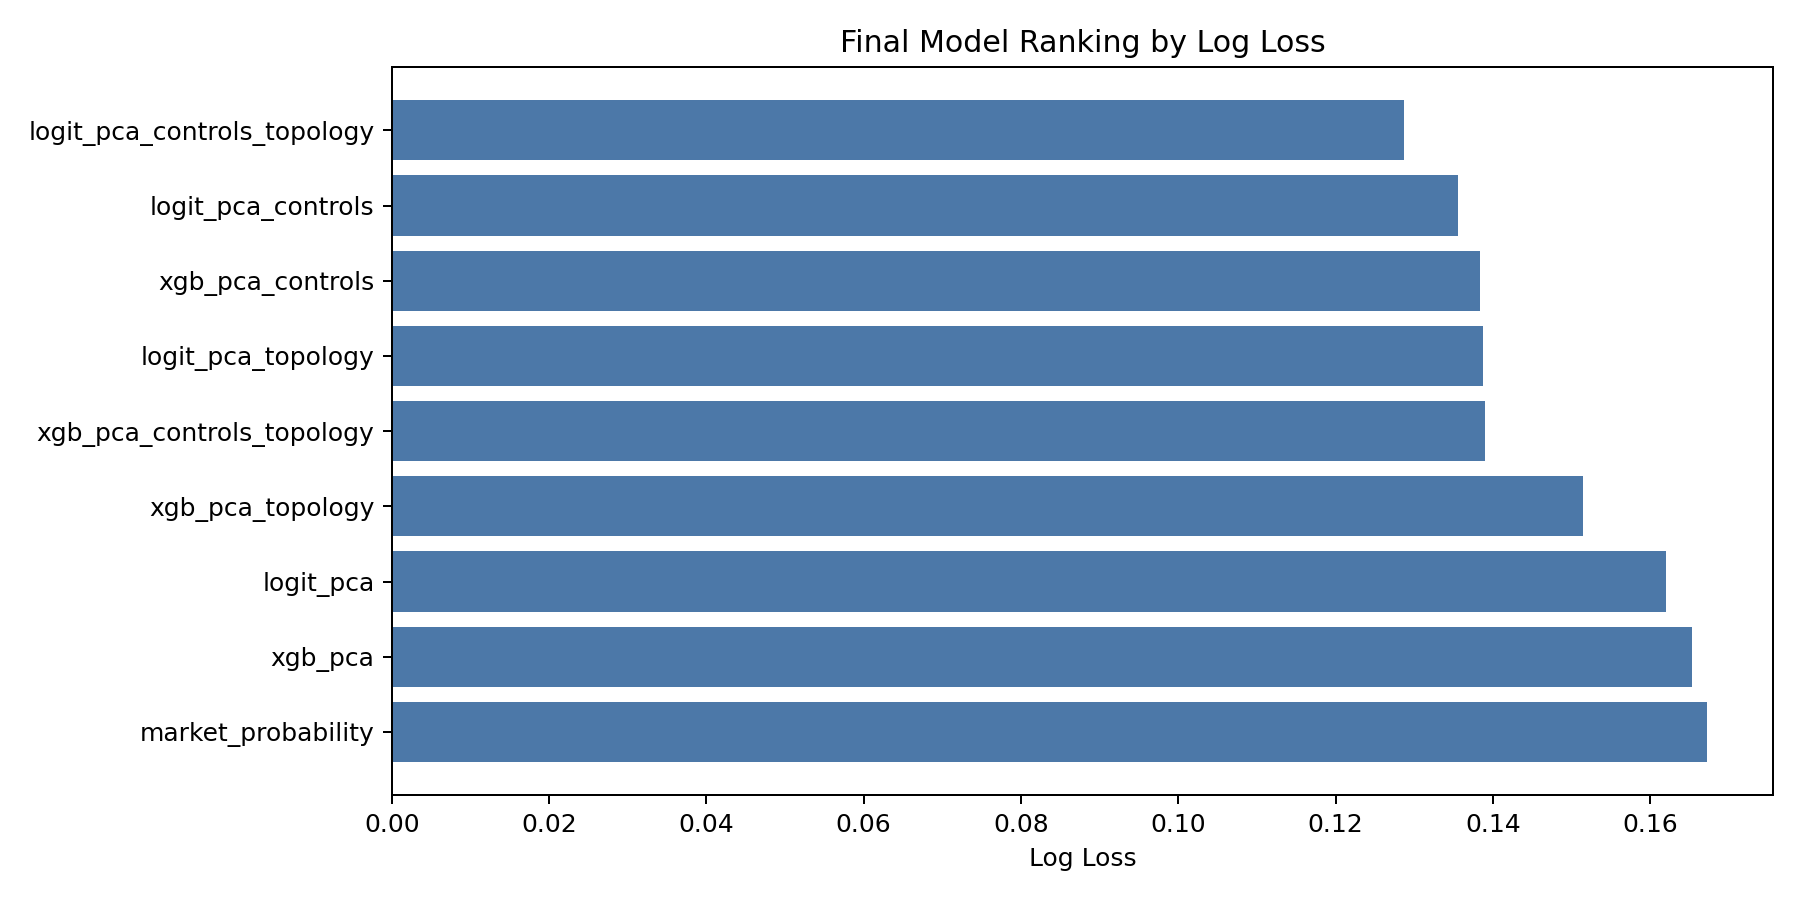

brier_ranking.png


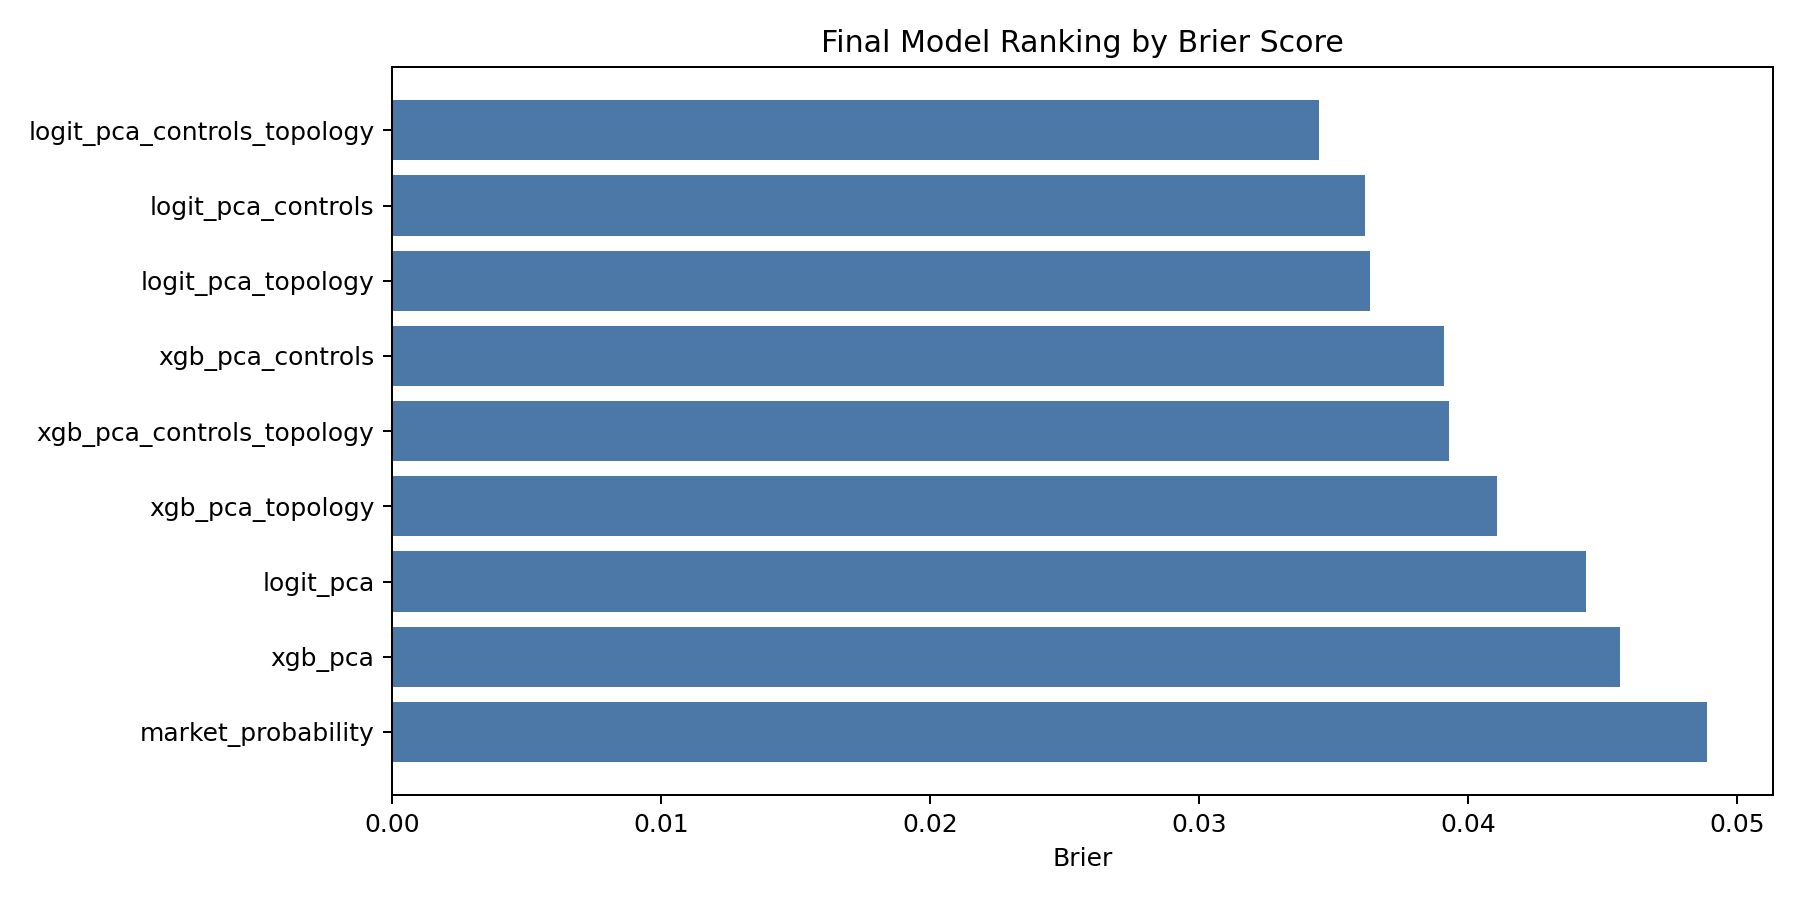

fold_level_deltas.png


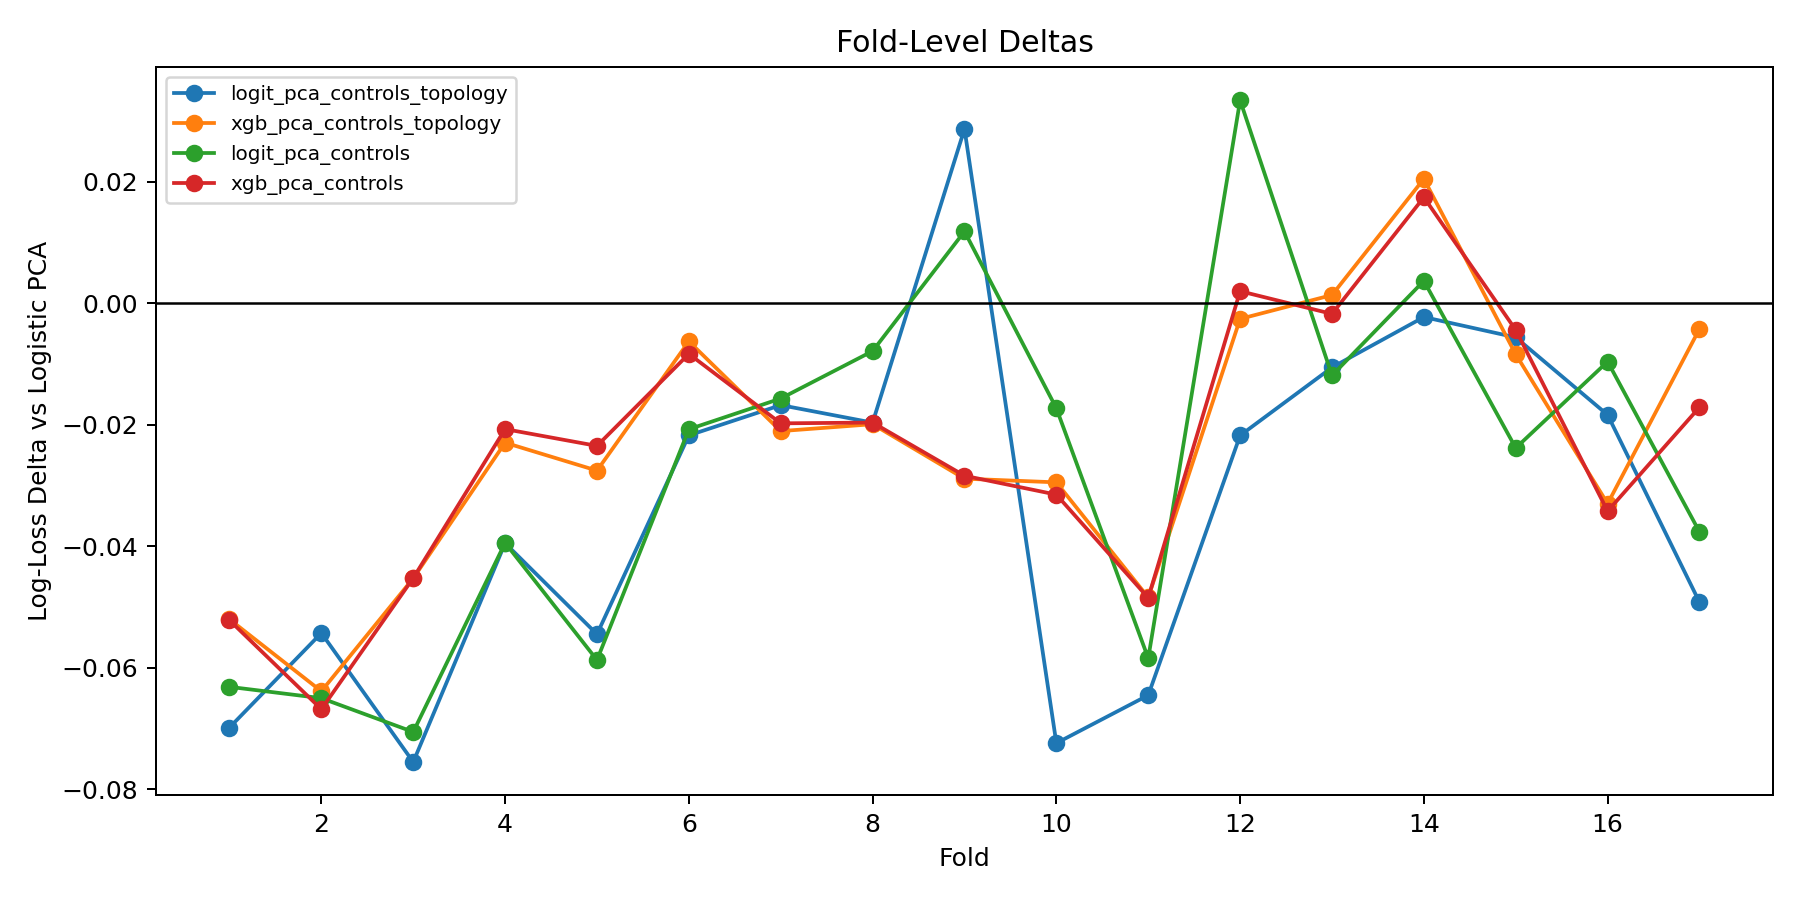

locked_holdout_log_loss.png


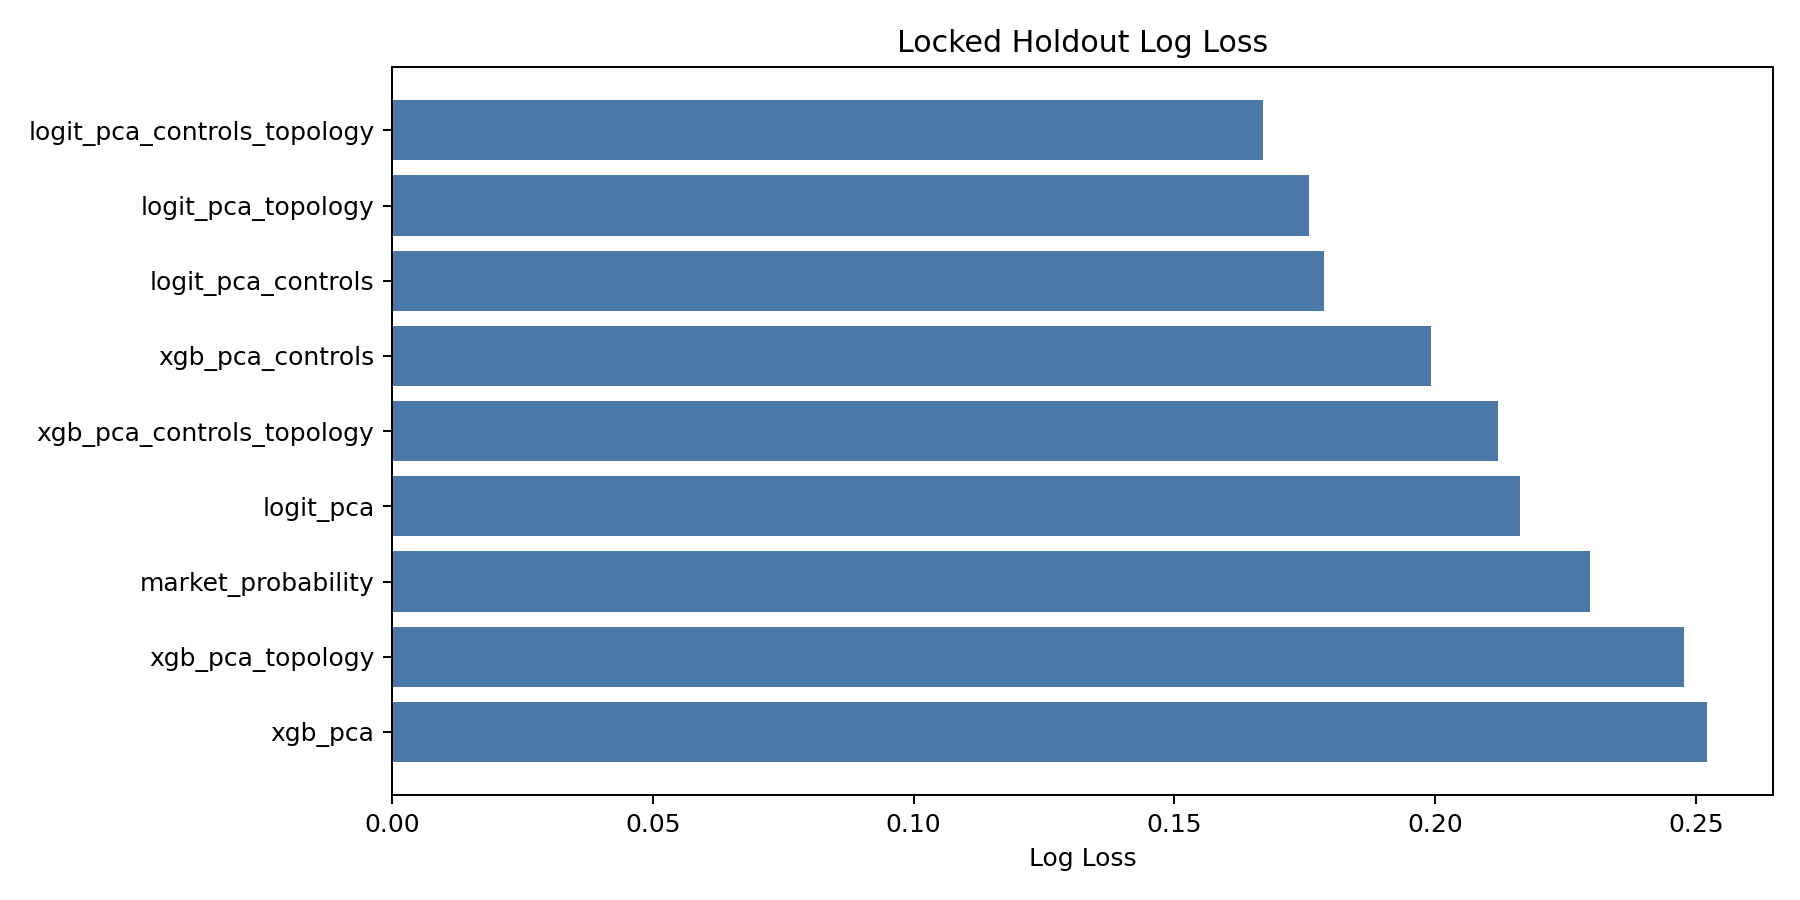

calibration_curves.png


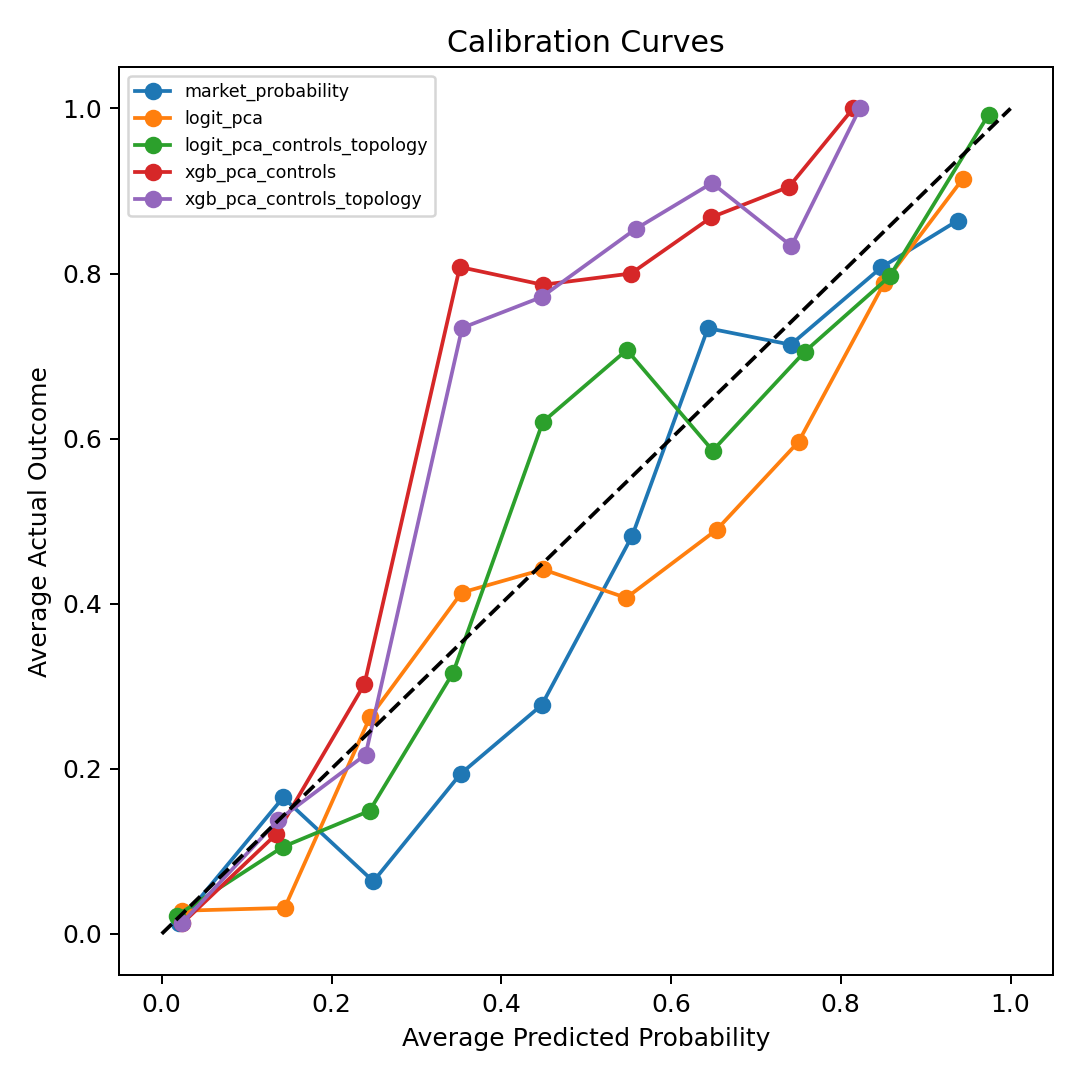

bootstrap_ci.png


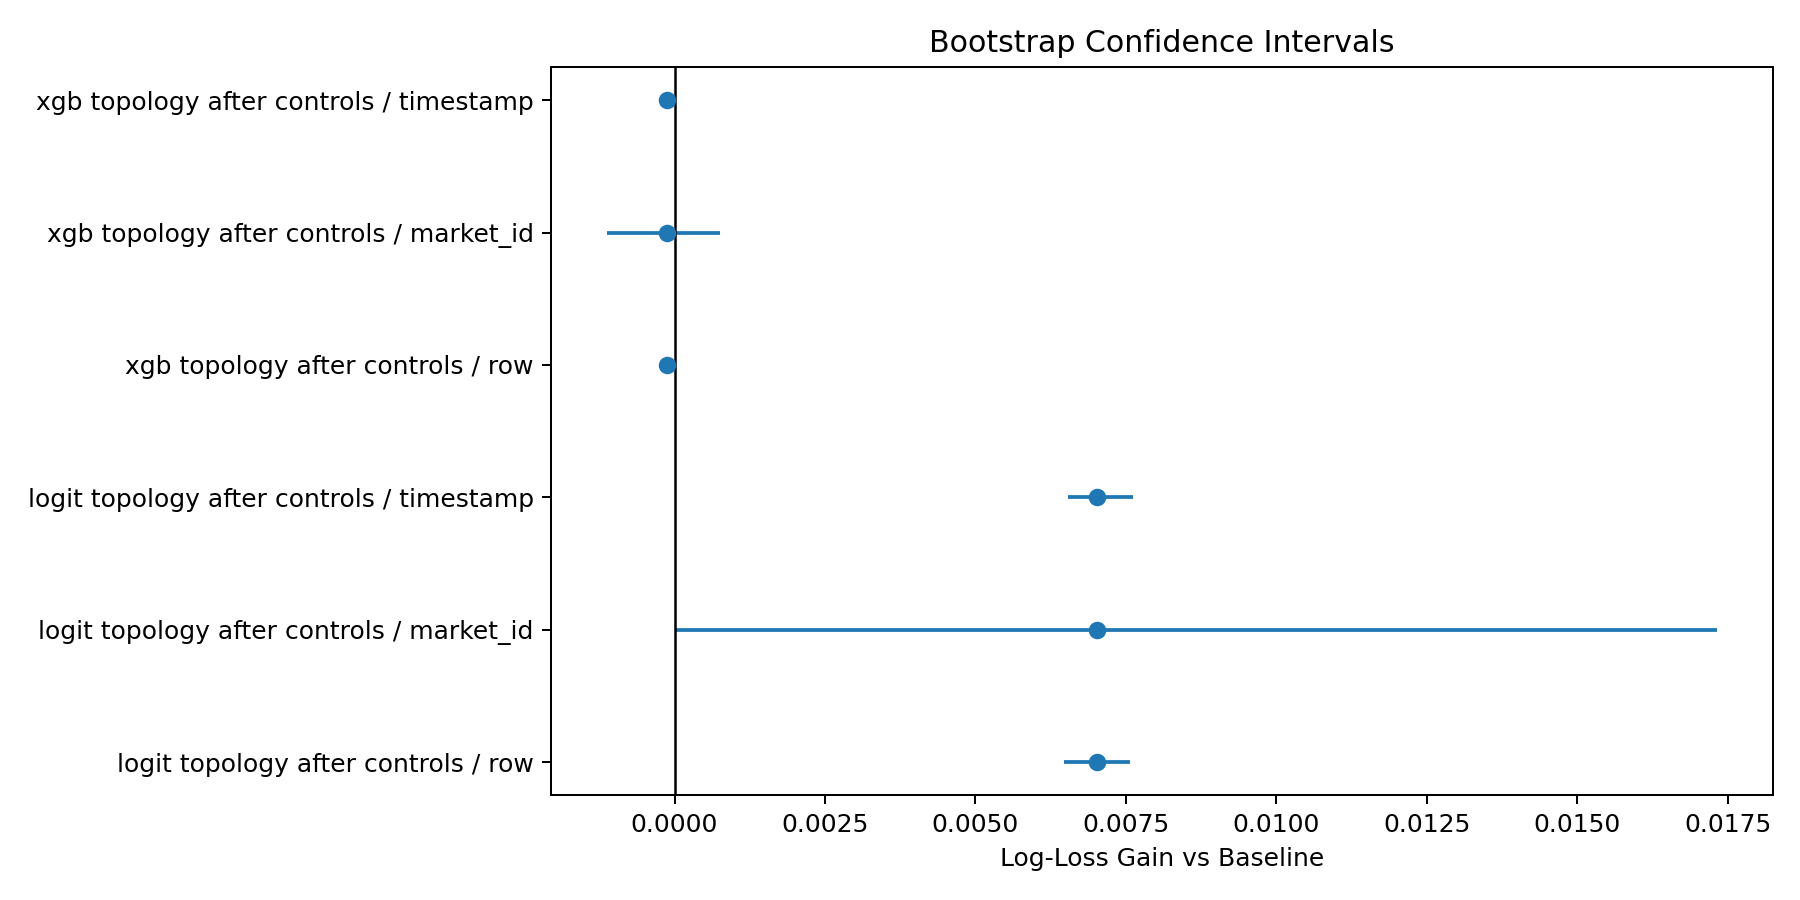

domain_level_delta.png


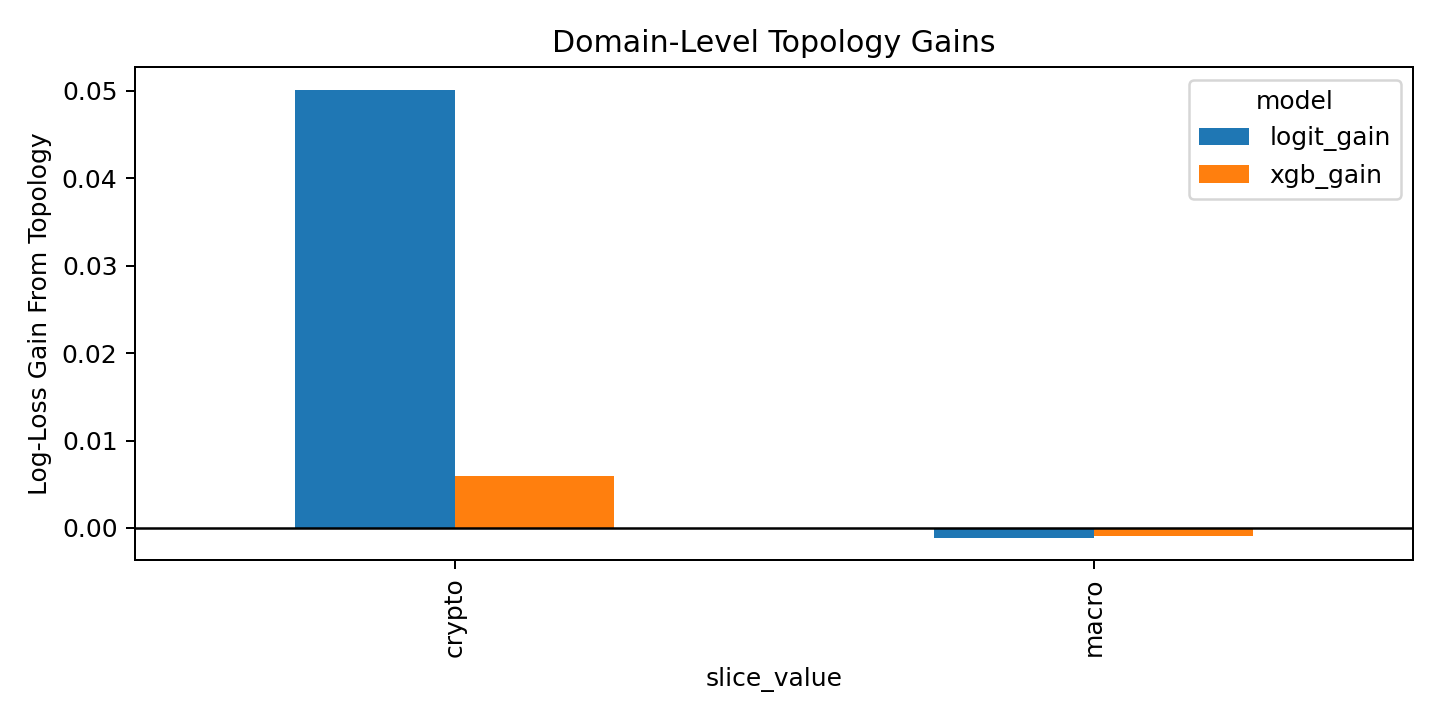

ablation_chart.png


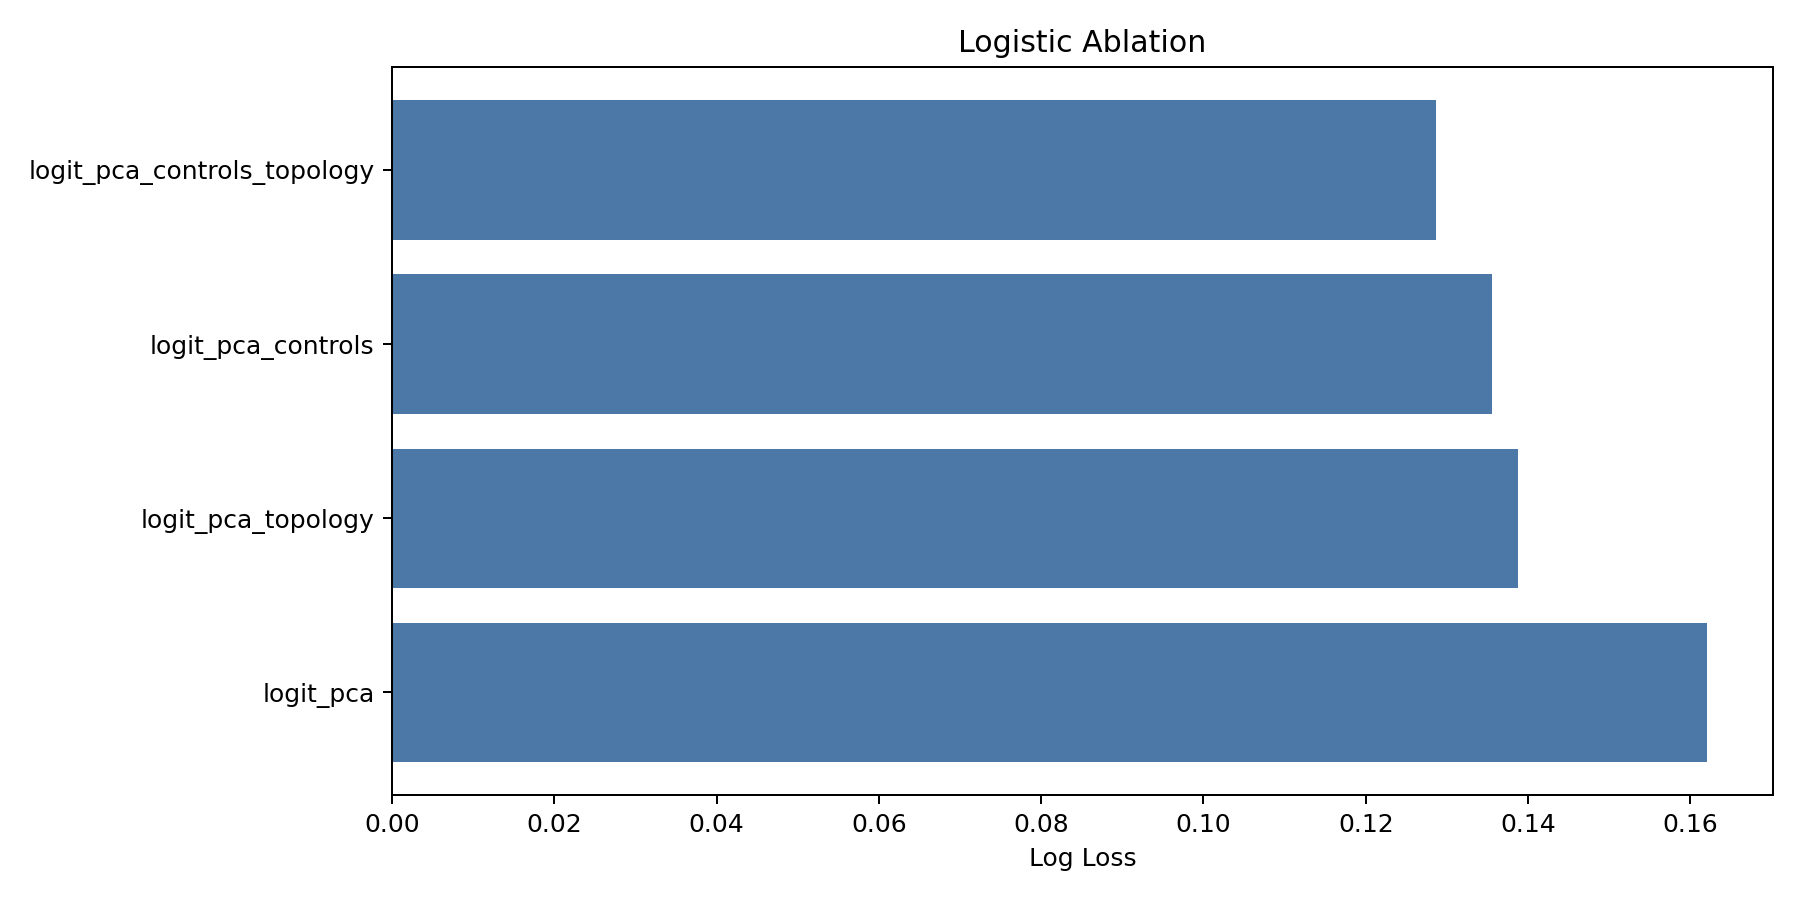

xgboost_comparison.png


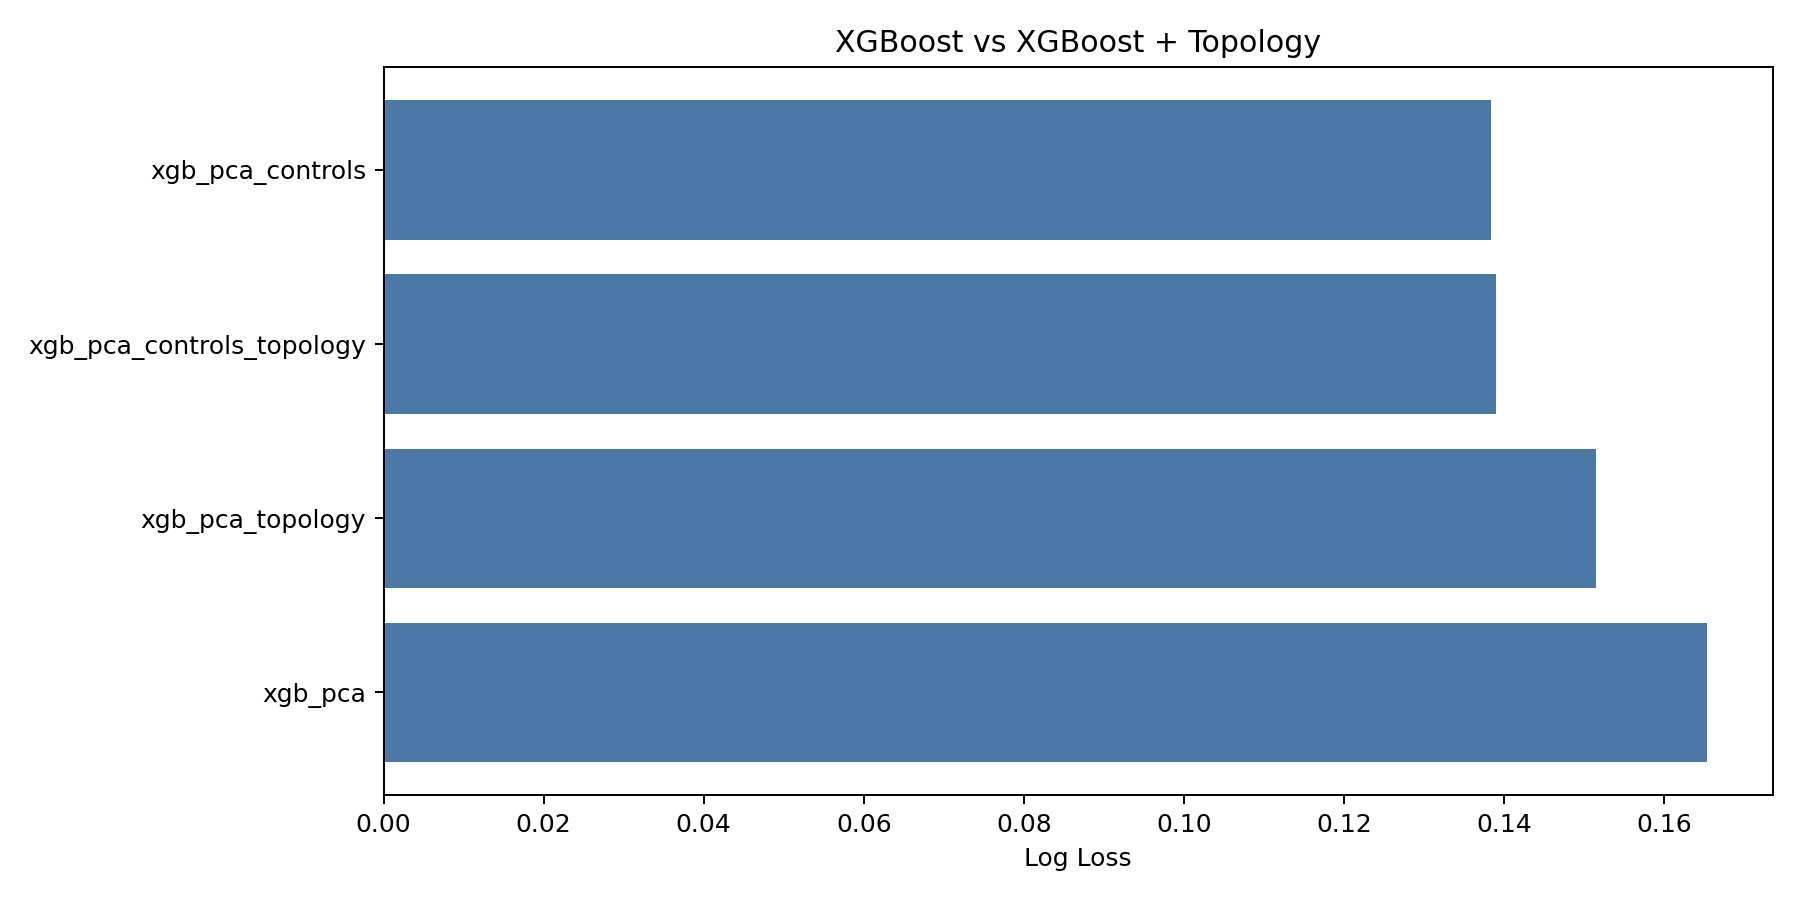

In [5]:
from IPython.display import Image, display

for name in [
    "log_loss_ranking.png",
    "brier_ranking.png",
    "fold_level_deltas.png",
    "locked_holdout_log_loss.png",
    "calibration_curves.png",
    "bootstrap_ci.png",
    "domain_level_delta.png",
    "ablation_chart.png",
    "xgboost_comparison.png",
]:
    print(name)
    display(Image(filename=str(FIG / name)))

## Key Statistical Tests

In [6]:
stat_tests

,comparison,candidate,baseline,cluster,n_units,log_loss_gain,log_loss_ci_low,log_loss_ci_high,brier_gain,brier_ci_low,brier_ci_high,log_loss_folds_improved,brier_folds_improved
0,logit topology after controls,logit_pca_controls_topology,logit_pca_controls,row,282976,0.007024,0.006472,0.007575,0.002012,0.001859,0.002152,NaN,NaN
1,logit topology after controls,logit_pca_controls_topology,logit_pca_controls,market_id,105,0.007024,0.000013,0.017326,0.002012,-0.000505,0.005051,NaN,NaN
2,logit topology after controls,logit_pca_controls_topology,logit_pca_controls,timestamp,5712,0.007024,0.006532,0.007617,0.002012,0.001871,0.002161,NaN,NaN
3,logit topology after controls,logit_pca_controls_topology,logit_pca_controls,fold_count,17,0.006871,NaN,NaN,0.001719,NaN,NaN,12.0,11.0
4,xgb topology after controls,xgb_pca_controls_topology,xgb_pca_controls,row,282976,-0.000129,-0.000204,-0.000052,-0.000103,-0.000133,-0.000070,NaN,NaN
5,xgb topology after controls,xgb_pca_controls_topology,xgb_pca_controls,market_id,105,-0.000129,-0.001126,0.000750,-0.000103,-0.000538,0.000322,NaN,NaN
6,xgb topology after controls,xgb_pca_controls_topology,xgb_pca_controls,timestamp,5712,-0.000129,-0.000213,-0.000056,-0.000103,-0.000130,-0.000075,NaN,NaN
7,xgb topology after controls,xgb_pca_controls_topology,xgb_pca_controls,fold_count,17,-0.000622,NaN,NaN,-0.000191,NaN,NaN,8.0,7.0
8,logit controls+topology after PCA,logit_pca_controls_topology,logit_pca,row,282976,0.034185,0.033292,0.035078,0.010790,0.010549,0.011040,NaN,NaN
9,logit controls+topology after PCA,logit_pca_controls_topology,logit_pca,market_id,105,0.034185,0.008785,0.061426,0.010790,0.003470,0.021472,NaN,NaN


## Calibration

In [7]:
calibration.groupby("model", as_index=False).agg(ece=("ece", "mean"), n_obs=("n_obs", "sum")).sort_values("ece")

,model,ece,n_obs
3,logit_pca_topology,0.030464,282976
0,logit_pca,0.031550,282976
1,logit_pca_controls,0.031683,282976
2,logit_pca_controls_topology,0.034724,282976
5,xgb_pca,0.036284,282976
8,xgb_pca_topology,0.043584,282976
7,xgb_pca_controls_topology,0.050652,282976
6,xgb_pca_controls,0.050862,282976
4,market_probability,0.058023,282976


## Domain Robustness

In [8]:
domain = results[results["slice_type"].eq("broad_domain")]
domain.pivot_table(index="slice_value", columns="model", values="log_loss", aggfunc="mean")

model,logit_pca,logit_pca_controls,logit_pca_controls_topology,logit_pca_topology,market_probability,xgb_pca,xgb_pca_controls,xgb_pca_controls_topology,xgb_pca_topology
slice_value,,,,,,,,,
crypto,0.524598,0.513192,0.463050,0.519644,0.496170,0.561972,0.418929,0.412964,0.508926
macro,0.137480,0.117007,0.118099,0.122547,0.129123,0.145753,0.131856,0.132729,0.139713


## Interpretation

The final comparison supports the paper framing that local topology is an incremental signal for the linear/logistic benchmark. XGBoost does not improve over the logistic controls model here, and topology does not improve XGBoost after controls, suggesting nonlinear tree models absorb or fail to exploit the same local-structure information.